In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../../data/phen/correlation/phenotypic_weather_obregon_correlation_151617.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/one


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 63.933253955421485
R2 -> 0.5756360228812109
MAPE -> 0.0858019545066517


{'d2_absolute_error_score': 0.3551390627904941,
 'd2_pinball_score': 0.3551390627904941,
 'd2_tweedie_score': 0.5756360228812109,
 'explained_variance_score': 0.5866328530222147,
 'max_error': 282.2394680895817,
 'mean_absolute_error': 44.99678796758794,
 'mean_absolute_percentage_error': 0.0858019545066517,
 'mean_gamma_deviance': 0.014811889514823304,
 'mean_poisson_deviance': 7.587150688539752,
 'mean_squared_error': 4087.4609613284165,
 'mean_squared_log_error': 0.016493408901486553,
 'median_absolute_error': 35.47456653412479,
 'r2_score': 0.5756360228812109,
 'root_mean_squared_error': 63.933253955421485,
 'root_mean_squared_log_error': 0.12842666740785014}

Plots:

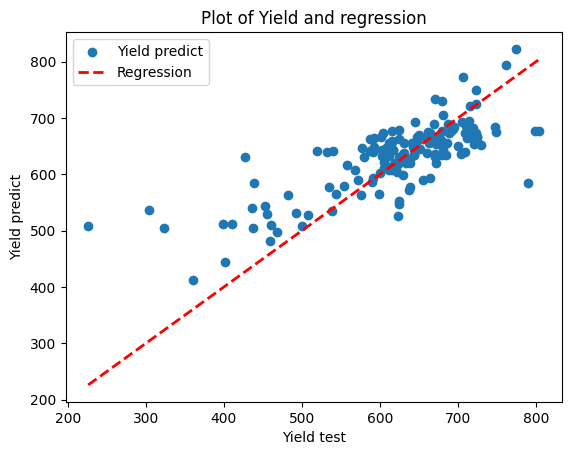

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118, 'predict': 508.3512680895817, 'error': 1.248229716846187},
 {'truth': 304.5419,
  'predict': 535.9485583558219,
  'error': 0.7598516274963212},
 {'truth': 322.9881, 'predict': 505.2143574417058, 'error': 0.564188765597574},
 {'truth': 427.0, 'predict': 631.4943602023122, 'error': 0.47890950867052046},
 {'truth': 438.9351,
  'predict': 584.0120565772692,
  'error': 0.3305202900776657},
 {'truth': 398.2896,
  'predict': 511.0614760037589,
  'error': 0.2831403983527536},
 {'truth': 790.0426,
  'predict': 585.1085859008742,
  'error': 0.2593961567377832},
 {'truth': 409.865,
  'predict': 512.3997960596516,
  'error': 0.25016724057836515},
 {'truth': 436.0, 'predict': 540.2262697434912, 'error': 0.2390510773933285},
 {'truth': 519.2414,
  'predict': 641.1498429694786,
  'error': 0.23478182396372602},
 {'truth': 532.0, 'predict': 640.0321986843807, 'error': 0.20306804263981326},
 {'truth': 453.0, 'predict': 542.9448840890778, 'error': 0.19855382801120938},
 {'truth': 540